# Healthcare Cost Prediction - Regression Track (Review 1)
**Course**: 23CSE301 Machine Learning - Capstone Project
**Project Title**: Healthcare Cost Prediction and Patient Risk Intelligence Using Machine Learning
**Dataset**: Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)
**Regression Target**: `annual_medical_cost`

---
### Academic Integrity Note
Per course guidelines, AI code scaffolding is used for code setup and structure. All analytical observations and domain interpretations are marked with **`TODO` placeholders** for student authoring.

Source/Citation: TODO — add source if external code was used.

## 1. Environment & Setup
Import required libraries and configure global random state (`random_state=42`).

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.model_training as model_training
import app.utils as utils

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Setup complete. Random state set to 42.')

Setup complete. Random state set to 42.


## SECTION A — DATASET & EDA (4 MARKS)
In this section, we audit dataset dimensions, datatypes, missing values, duplicates, descriptive statistics, and plot feature distributions.

In [2]:
# 1. Load Dataset & Audit Shape / Types
df_raw = pd.read_csv(config.DATA_PATH)
print('Dataset Shape:', df_raw.shape)
print('\nData Types Summary:')
print(df_raw.dtypes.value_counts())
print('\nMissing Values Count per Column (Total):', df_raw.isnull().sum().sum())
print('Duplicate Rows Count:', df_raw.duplicated().sum())
df_raw.info()

Dataset Shape: (100000, 54)

Data Types Summary:
int64      31
float64    13
str        10
Name: count, dtype: int64

Missing Values Count per Column (Total): 30083


Duplicate Rows Count: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  

In [3]:
# 2. Descriptive Statistics
df_raw.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


### Observation — Dataset & Audit Summary
TODO: Write observation after inspecting dataset shape, missing values, and descriptive statistics.

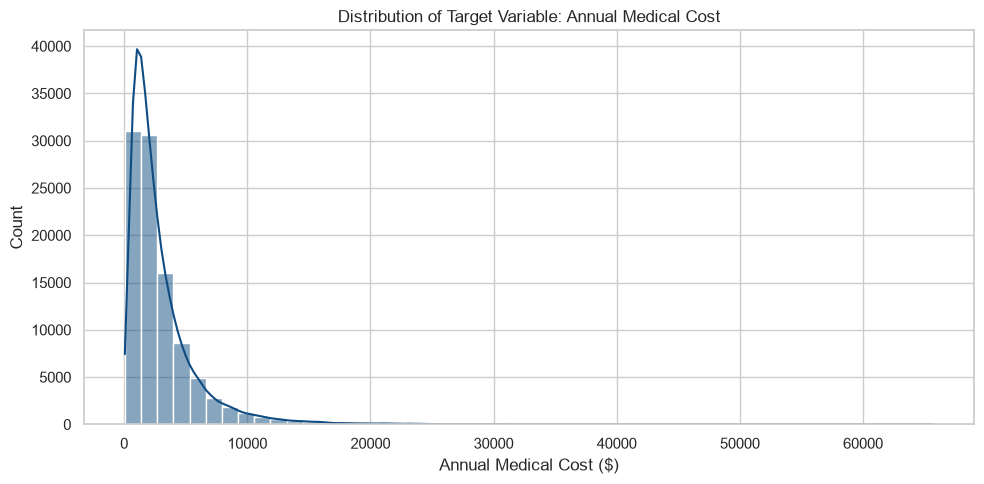

In [4]:
# 3. Target Distribution Plot (annual_medical_cost)
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['annual_medical_cost'], kde=True, bins=50, color='#0F4C81')
plt.title('Distribution of Target Variable: Annual Medical Cost')
plt.xlabel('Annual Medical Cost ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Observation — Target Distribution
TODO: Write observation after inspecting this plot.

/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_34236/2168322235.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='smoker', ax=axes[1, 0], palette='Blues_r')
/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_34236/2168322235.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='sex', ax=axes[1, 1], palette='Set2')
/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_34236/2168322235.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='plan_type', ax=axes[1, 2],

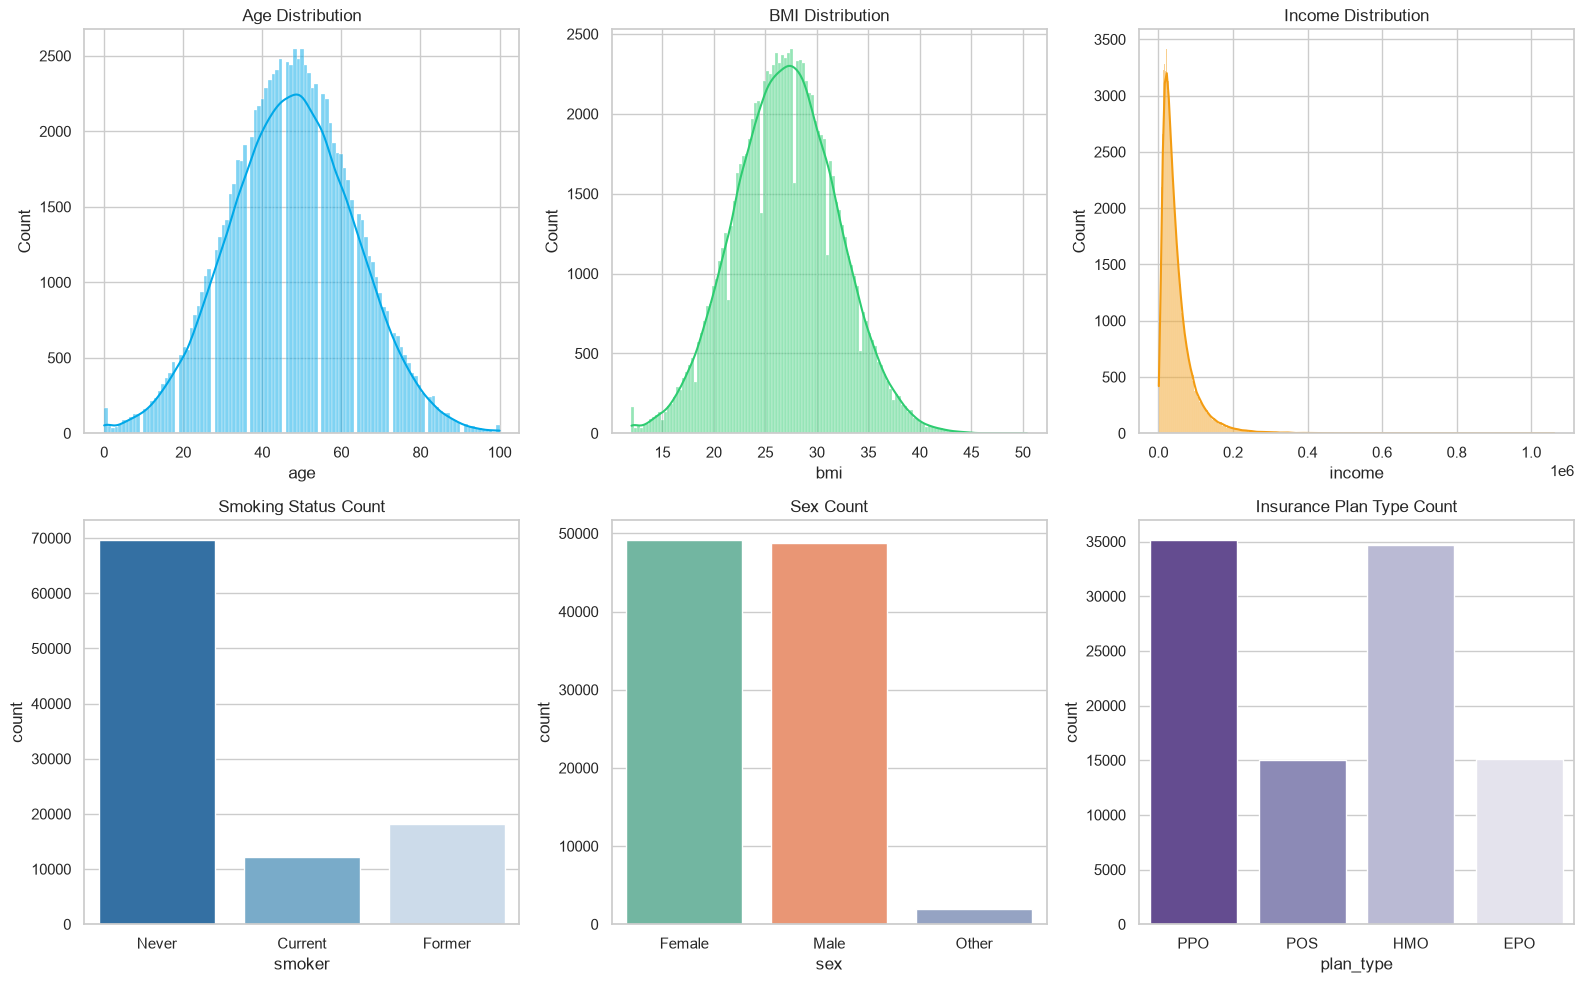

In [5]:
# 4. Feature Distribution Plots (Key Numerical & Categorical Features)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
sns.histplot(df_raw['age'], kde=True, ax=axes[0, 0], color='#00A8E8')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df_raw['bmi'], kde=True, ax=axes[0, 1], color='#2ECC71')
axes[0, 1].set_title('BMI Distribution')

sns.histplot(df_raw['income'], kde=True, ax=axes[0, 2], color='#F39C12')
axes[0, 2].set_title('Income Distribution')

sns.countplot(data=df_raw, x='smoker', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Smoking Status Count')

sns.countplot(data=df_raw, x='sex', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Sex Count')

sns.countplot(data=df_raw, x='plan_type', ax=axes[1, 2], palette='Purples_r')
axes[1, 2].set_title('Insurance Plan Type Count')
plt.tight_layout()
plt.show()

### Observation — Feature Distributions
TODO: Write observation after inspecting this plot.

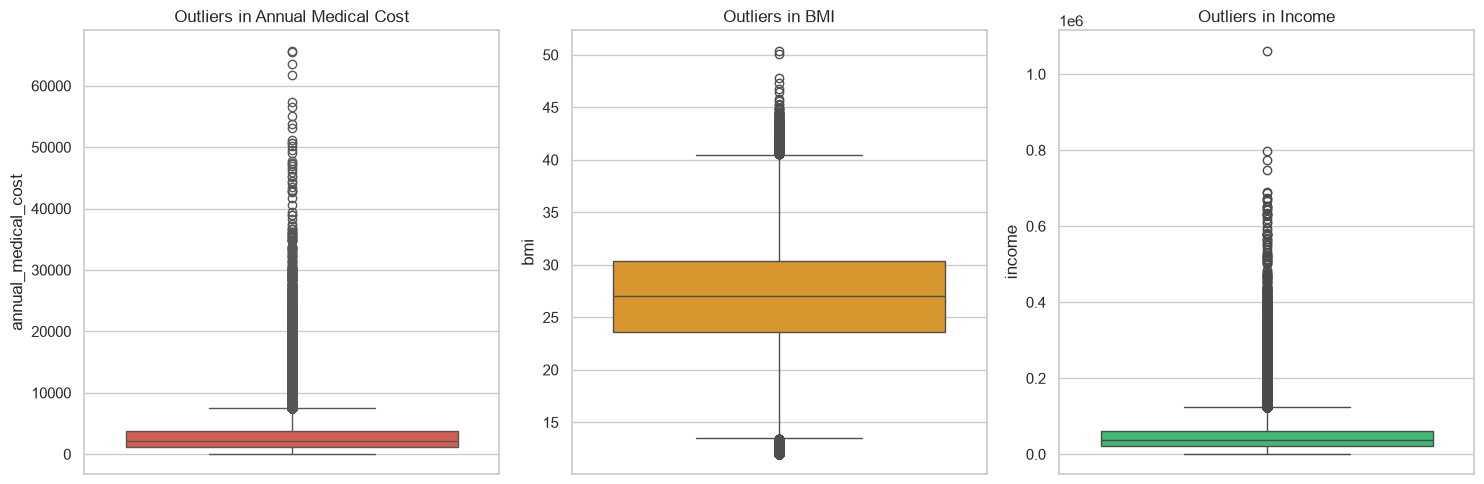

In [6]:
# 5. Outlier Analysis (Boxplots)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df_raw['annual_medical_cost'], ax=axes[0], color='#E74C3C')
axes[0].set_title('Outliers in Annual Medical Cost')

sns.boxplot(y=df_raw['bmi'], ax=axes[1], color='#F39C12')
axes[1].set_title('Outliers in BMI')

sns.boxplot(y=df_raw['income'], ax=axes[2], color='#2ECC71')
axes[2].set_title('Outliers in Income')
plt.tight_layout()
plt.show()

### Observation — Outlier Analysis
TODO: Write observation after inspecting this plot.

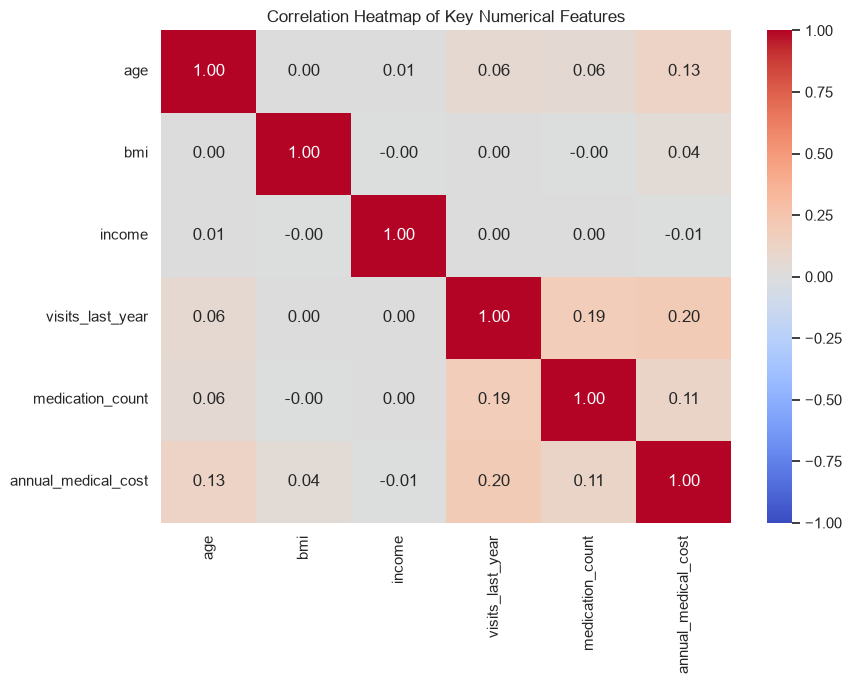

In [7]:
# 6. Correlation Heatmap
num_cols_eda = ['age', 'bmi', 'income', 'visits_last_year', 'medication_count', 'annual_medical_cost']
plt.figure(figsize=(9, 7))
sns.heatmap(df_raw[num_cols_eda].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.tight_layout()
plt.show()

### Observation — Correlation Heatmap
TODO: Write observation after inspecting this plot.

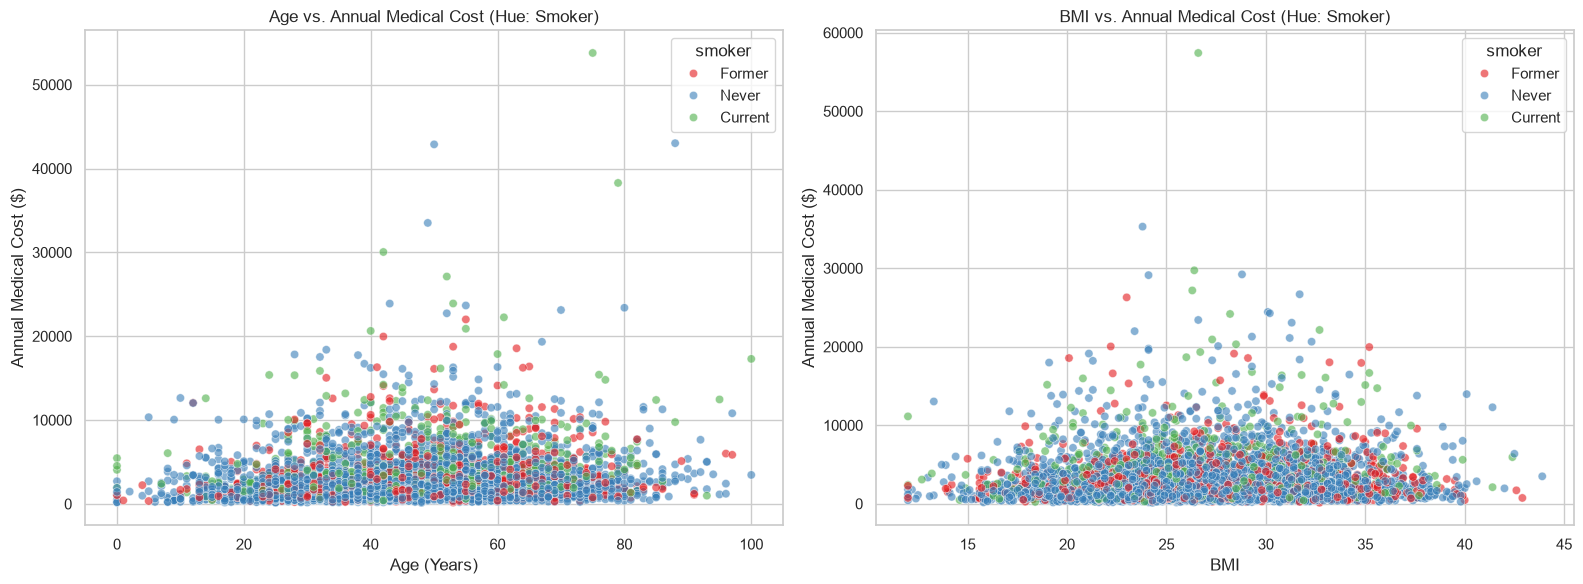

In [8]:
# 7. Scatter Plots: Feature-Target Relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df_raw.sample(5000), x='age', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1', ax=axes[0])
axes[0].set_title('Age vs. Annual Medical Cost (Hue: Smoker)')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Annual Medical Cost ($)')

sns.scatterplot(data=df_raw.sample(5000), x='bmi', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1', ax=axes[1])
axes[1].set_title('BMI vs. Annual Medical Cost (Hue: Smoker)')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Annual Medical Cost ($)')
plt.tight_layout()
plt.show()

### Observation — Scatter Plots (Feature-Target Relationships)
TODO: Write observation after inspecting this plot.

## SECTION B — PREPROCESSING & FEATURE ENGINEERING (3 MARKS)
We implement missing value handling, feature engineering, categorical encoding, scaling, and train/test splitting (`random_state=42`).

### Feature Leakage Audit Table
| Feature | Potential Leakage? | Reason | Action | Justification |
| :--- | :--- | :--- | :--- | :--- |
| `risk_score` | Yes | Direct mathematical precursor to risk target | Exclude | Prevents artificial target leakage |
| `total_claims_paid` | Yes | Post-hoc downstream value (`claims_count` * `avg_claim_amount`) | Exclude from predictors | Prevents post-hoc reimbursement leakage |
| `annual_premium` | No | Pre-computed policy enrollment cost | Retain | Valid actuarial predictor |
| `monthly_premium` | No | Direct linear scaling of annual premium | Retain | Valid financial predictor |
| `claims_count` | Partial | Pre-existing utilization frequency | Retain | Valid utilization metric |

### Missing Values Handling Strategy
TODO: Provide justification for missing value handling strategy.

In [9]:
# Preprocessing Pipeline Execution (Strict Train/Test Split Fit)
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_regression()
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)
print('\nEngineered Features Verified:')
print([col for col in X_train.columns if col in config.ENGINEERED_FEATURES])

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)

Engineered Features Verified:
['BMI_Category', 'Age_Group', 'Lifestyle_Risk_Score', 'Hospital_Utilization_Score', 'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases', 'Claim_Severity_Index']


## SECTION C — REGRESSION TRACK (9 MARKS)
We train all 10 mandatory regression algorithms, evaluate them on the same held-out test set ($R^2$, $RMSE$, $MAE$), tune top ensemble models, and run 5-fold cross validation.

In [10]:
# Train 10 Regression Models
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
df_results, cv_scores = model_training.train_regression(X_train, X_test, y_train, y_test, preprocessor)

Training SVR (on 8,000 row subsample for speed)...


Training KNN Regressor (on 8,000 row subsample for speed)...

Evaluating Baseline Regression Models:
Linear Regression              | R2: 0.9662 | RMSE: 576.65 | MAE: 312.87
Ridge Regression               | R2: 0.9662 | RMSE: 576.63 | MAE: 312.86
Lasso Regression               | R2: 0.9662 | RMSE: 576.30 | MAE: 310.23
ElasticNet                     | R2: 0.9172 | RMSE: 902.65 | MAE: 524.57
Polynomial Regression          | R2: 0.9665 | RMSE: 574.39 | MAE: 319.41


Decision Tree Regressor        | R2: 0.9927 | RMSE: 267.59 | MAE: 136.81
Random Forest Regressor        | R2: 0.9964 | RMSE: 188.45 | MAE: 76.51
Gradient Boosting Regressor    | R2: 0.9969 | RMSE: 173.62 | MAE: 88.12


Support Vector Regressor       | R2: 0.7530 | RMSE: 1559.03 | MAE: 391.73
KNN Regressor                  | R2: 0.8002 | RMSE: 1402.00 | MAE: 917.33

--- Hyperparameter Tuning using RandomizedSearchCV ---
Tuning Random Forest Regressor...


Best RF Params: {'regressor__n_estimators': 50, 'regressor__min_samples_split': 5, 'regressor__max_depth': None}
Tuning Gradient Boosting Regressor...


...

Fitting best Gradient Boosting on full train set...


Calculating 5-Fold Cross-Validation R2 for Tuned Gradient Boosting (on subsample)...


5-Fold CV R2 for Tuned Gradient Boosting: 0.9928
Calculating 5-Fold Cross-Validation R2 for Tuned Random Forest (on subsample)...


5-Fold CV R2 for Tuned Random Forest: 0.9865


Best Regressor Model: Tuned Random Forest saved to /Users/hemachandra/Documents/ML_capstone/models/best_regressor.joblib


### Consolidated Regression Comparison DataFrame
Models ranked by $R^2$ score on the held-out test split:

In [11]:
df_results

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.997785,147.619566,7.173230
1,Gradient Boosting Regressor,0.996936,173.624191,88.120156
2,Random Forest Regressor,0.996391,188.445210,76.507044
3,Tuned Gradient Boosting,0.996341,189.759281,87.366257
4,Decision Tree Regressor,0.992723,267.588951,136.812332
5,Polynomial Regression,0.966471,574.392488,319.410637
6,Lasso Regression,0.966249,576.297724,310.230972
7,Ridge Regression,0.966210,576.628826,312.856146
8,Linear Regression,0.966207,576.648963,312.865126
9,ElasticNet,0.917198,902.652821,524.570098


In [12]:
# 5-Fold Cross Validation Results for Top 2 Models
print('5-Fold Cross Validation R2 Scores (Top 2 Models):')
for model_name, score in cv_scores.items():
    print(f'Model: {model_name:<30} | Mean CV R2: {score:.4f}')

5-Fold Cross Validation R2 Scores (Top 2 Models):
Model: Tuned Gradient Boosting        | Mean CV R2: 0.9928
Model: Tuned Random Forest            | Mean CV R2: 0.9865


### Regression Visualizations & Model Diagnostics

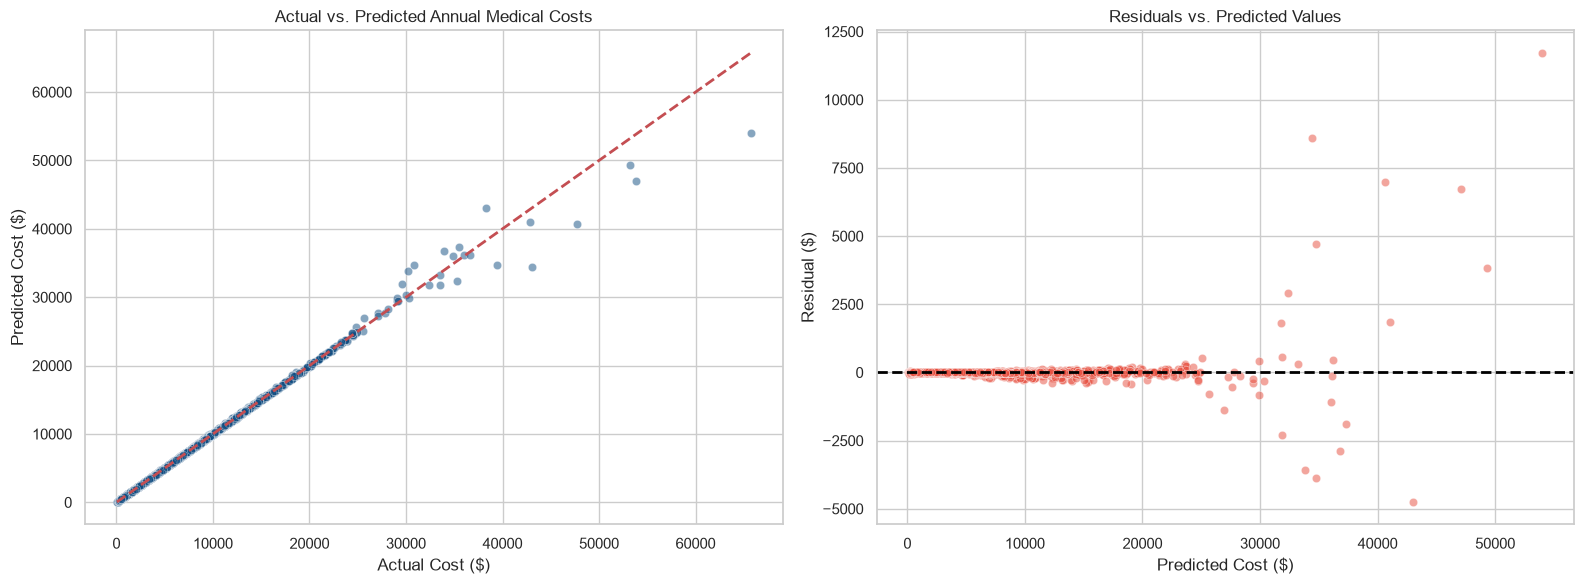

In [13]:
best_model = joblib.load(config.BEST_REGRESSOR_PATH)
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# 1. Actual vs Predicted & 2. Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=axes[0], color='#0F4C81')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Annual Medical Costs')
axes[0].set_xlabel('Actual Cost ($)')
axes[0].set_ylabel('Predicted Cost ($)')

sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[1], color='#E74C3C')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Cost ($)')
axes[1].set_ylabel('Residual ($)')
plt.tight_layout()
plt.show()

### Observation — Predicted vs Actual & Residual Plots
TODO: Write observation after inspecting this plot.

/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_34236/2484450779.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')


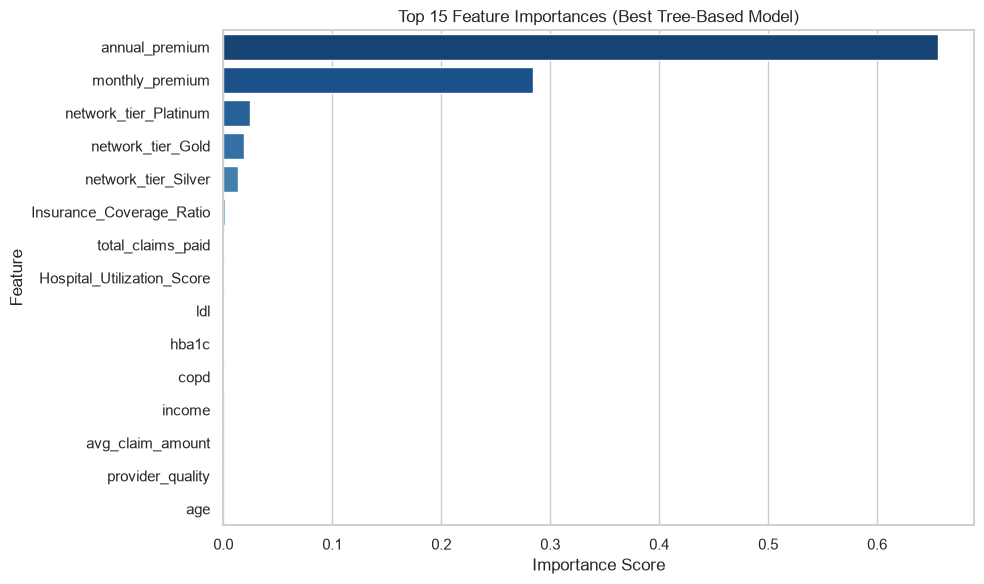

In [14]:
# 3. Tree-based Feature Importance Plot
if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    feat_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    importances = best_model.named_steps['regressor'].feature_importances_
    clean_names = [n.split('__')[1] if '__' in n else n for n in feat_names]
    feat_imp = pd.DataFrame({'Feature': clean_names, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')
    plt.title('Top 15 Feature Importances (Best Tree-Based Model)')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### Observation — Feature Importance Plot
TODO: Write observation after inspecting this plot.

## FINAL REVIEW-1 OUTPUT & CHECKLIST

### Review-1 Requirements Verification
| Section | Criterion | Status |
| :--- | :--- | :---: |
| Section A | Dataset Loaded & Shape Shown | Verified |
| Section A | Dtypes & Missing Values Audited | Verified |
| Section A | Target & Feature Distributions Plotted | Verified |
| Section A | Correlation Heatmap & Scatter Plots | Verified |
| Section B | Missing Values Handled & Scaling/Encoding | Verified |
| Section B | Data Leakage Audit Table & Train/Test Split | Verified |
| Section C | All 10 Regression Models Trained & Evaluated | Verified |
| Section C | Hyperparameter Tuning & 5-Fold Cross Validation | Verified |
| Section C | Residuals, Actual-vs-Predicted, and Feature Importance Plots | Verified |

### Human-Written TODO Checklist
- [ ] Write observation for Dataset Audit & Summary
- [ ] Write observation for Target Distribution Plot
- [ ] Write observation for Feature Distributions Plot
- [ ] Write observation for Outlier Analysis Boxplots
- [ ] Write observation for Correlation Heatmap
- [ ] Write observation for Scatter Plots
- [ ] Provide justification for missing value handling strategy
- [ ] Write observation for Predicted vs Actual & Residual Plots
- [ ] Write observation for Tree-Based Feature Importance Plot